# MatMul-Free Language Model - Training Notebook v3
Testing and training the HGRN-Bit model with Triton kernels on AWS SageMaker

In [3]:
# Cell 1: Environment Check
import torch
import sys
sys.path.append('.')
print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
    if torch.cuda.device_count() > 1:
        for i in range(torch.cuda.device_count()):
            print(f'GPU {i}: {torch.cuda.get_device_name(i)}')

PyTorch version: 2.6.0+cu124
CUDA available: True
GPU: NVIDIA A10G
GPU memory: 23.7 GB
GPU 0: NVIDIA A10G
GPU 1: NVIDIA A10G
GPU 2: NVIDIA A10G
GPU 3: NVIDIA A10G


In [4]:
# Cell 2: Imports
from src.modules import RMSNorm, FusedCrossEntropyLoss, swiglu
from src.models.hgrn_bit.configuration_hgrn_bit import HGRNBitConfig
from src.models.hgrn_bit.modeling_hgrn_bit import HGRNBitForCausalLM

print('Imports successful')

Imports successful


In [5]:
# Cell 3: Test Model Config
config = HGRNBitConfig(
    vocab_size=32000,
    hidden_size=512,  # Small for testing
    num_hidden_layers=2,  # Just 2 layers
    max_position_embeddings=2048
)

print('Config created')

Config created


In [6]:
# Cell 4: Create Test Model
model = HGRNBitForCausalLM(config)
print(f'Model created with {sum(p.numel() for p in model.parameters()):,} parameters')

HGRNBitForCausalLM has generative capabilities, as `prepare_inputs_for_generation` is explicitly defined. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by loading the model with an auto class. See https://huggingface.co/docs/transformers/en/model_doc/auto#auto-classes
  - If you are the owner of the model architecture code, please modify your model class such that it inherits from `GenerationMixin` (after `PreTrainedModel`, otherwise you'll get an exception).
  - If you are not the owner of the model architecture class, please contact the model code owner to update it.


Model created with 39,597,056 parameters


In [7]:
# Cell 5: Move to GPU
device = torch.device('cuda')
model = model.to(device)
print('Model moved to GPU')

Model moved to GPU


In [8]:
# Cell 6: Test Forward Pass
input_ids = torch.randint(0, 32000, (2, 128)).to(device)  # batch=2, seq_len=128
print(f'Input shape: {input_ids.shape}')

with torch.no_grad():
    outputs = model(input_ids)
    print('Forward pass successful!')
    print(f'Output logits shape: {outputs.logits.shape}')
    print(f'GPU memory used: {torch.cuda.memory_allocated() / 1e9:.2f} GB')

print('\nMatMul-Free Language Model is working on GPU!')

Input shape: torch.Size([2, 128])
Forward pass successful!
Output logits shape: torch.Size([2, 128, 32000])
GPU memory used: 1.24 GB

MatMul-Free Language Model is working on GPU!


In [9]:
# Cell 7: Test FusedBitLinear
print("Testing FusedBitLinear...")
from src.ops.fusedbitnet import FusedBitLinear

bit_linear = FusedBitLinear(512, 256).cuda()
test_input = torch.randn(2, 128, 512).cuda()
bit_output = bit_linear(test_input)
print(f"FusedBitLinear output shape: {bit_output.shape}")
print(f"Memory after BitLinear: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

Testing FusedBitLinear...
FusedBitLinear output shape: torch.Size([2, 128, 256])
Memory after BitLinear: 1.24 GB


In [10]:
# Cell 8: Test HGRN Recurrent Operation
print("\nTesting HGRN recurrent operation...")
from src.ops.hgrn.recurrent_fuse import fused_recurrent_hgrn


Testing HGRN recurrent operation...


In [11]:
# Cell 9: Run HGRN Test
batch_size, num_heads, seq_len, head_dim = 2, 8, 128, 64
i = torch.randn(batch_size, num_heads, seq_len, head_dim).cuda()
f = torch.sigmoid(torch.randn(batch_size, num_heads, seq_len, head_dim)).cuda()

hgrn_output, final_state = fused_recurrent_hgrn(i, f, output_final_state=True)
print(f"HGRN output shape: {hgrn_output.shape}")
print(f"HGRN final state shape: {final_state.shape}")
print(f"Memory after HGRN: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

print("\nCustom operations working correctly!")

HGRN output shape: torch.Size([2, 8, 128, 64])
HGRN final state shape: torch.Size([2, 8, 64])
Memory after HGRN: 1.24 GB

Custom operations working correctly!


In [12]:
# Cell 10: Examine Dataset Structure
import os
import numpy as np

print("Examining SlimPajama dataset structure...")

dataset_path = "SlimPajama-6B-nanotron"
train_path = os.path.join(dataset_path, "train")

if os.path.exists(train_path):
    files = os.listdir(train_path)
    print(f"Found {len(files)} files in train directory")
    print("Sample files:", files[:5])

    sample_file = os.path.join(train_path, files[0])
    print(f"\nExamining file: {sample_file}")

    file_size = os.path.getsize(sample_file)
    print(f"File size: {file_size / 1e6:.1f} MB")

    try:
        data = np.load(sample_file)
        print(f"Loaded as numpy array - shape: {data.shape}, dtype: {data.dtype}")
        print(f"Sample tokens: {data[:20]}")
    except:
        try:
            with open(sample_file, 'rb') as f:
                raw_data = f.read(100)
            print(f"Raw bytes (first 100): {raw_data}")
        except Exception as e:
            print(f"Could not read file: {e}")
else:
    print(f"Dataset path not found: {dataset_path}")

Examining SlimPajama dataset structure...
Found 96 files in train directory
Sample files: ['tokens_shard_000005_remainder.ds', 'tokens_shard_000027.ds', 'tokens_shard_000007.ds', 'tokens_shard_000000.ds', 'tokens_shard_000049_remainder.ds']

Examining file: SlimPajama-6B-nanotron/train/tokens_shard_000005_remainder.ds
File size: 12.4 MB
Raw bytes (first 100): b'\x01\x00\x0f\x10m\x05\x91\x04Y\x05u\x01\x16\x01\xa9\x036\x01\x16\x01\x02\x10#Y\x9d\x06\x9b\x01\xd6\x01\xd6\x05n\t\x1eS6\x01\x16\x1c\xc1t\r\x00\xe8ti.\xa8\tu\x01\xd3>\xdat\xb9t\x875\xc2\\9\x01:#G\x0c\x88(B\x01\xc2JG\x026\x01Y7\x04\x12\x9b\x04\xd3\x01\r\x00(\x06\x07\x14\xc0\x1f\x07\x01\x13K\xd2 '


In [13]:
# Cell 11: PajamaDataset Class
import torch
from torch.utils.data import Dataset, DataLoader
import os
import numpy as np

# --- Configuration ---
train_path = "SlimPajama-6B-nanotron/train"
# ---------------------

class PajamaDataset(Dataset):
    def __init__(self, data_dir, seq_length=2048):
        self.data_dir = data_dir
        self.seq_length = seq_length
        
        if not os.path.isdir(data_dir):
            raise FileNotFoundError(f"Data directory not found: {data_dir}")
            
        self.files = [f for f in os.listdir(data_dir) if f.endswith('.ds')]
        self.files.sort()
        self.file_tokens = []
        self.cumulative_lengths = [0] 

        print(f"Loading {len(self.files)} files...")
        
        for file in self.files:
            file_path = os.path.join(data_dir, file)
            tokens = self._load_tokens(file_path)
            self.file_tokens.append(tokens)
            
            # Calculate how many full sequences can be extracted: (total_tokens - 1) // seq_length
            num_samples = (len(tokens) - 1) // seq_length if len(tokens) > 0 else 0
            self.cumulative_lengths.append(self.cumulative_lengths[-1] + num_samples)
            
        self.total_samples = self.cumulative_lengths[-1]
        print(f"Total samples: {self.total_samples}")

    def _load_tokens(self, file_path):
        # FIX: Changed element_size to 2 bytes for 16-bit unsigned integer ('<u2')
        element_size = 2
        
        try:
            with open(file_path, 'rb') as f:
                data = f.read()

            # Truncate any bytes that don't form a complete 2-byte token
            remainder = len(data) % element_size
            if remainder != 0:
                valid_length = len(data) - remainder
                data = data[:valid_length]
            
            if not data:
                return torch.empty(0, dtype=torch.long)

            # FIX: Used dtype.dtype('<u2') for 2-byte unsigned integer
            tokens_np = np.frombuffer(data, dtype=np.dtype('<u2')) 
            
            return torch.tensor(tokens_np, dtype=torch.long)
        
        except Exception as e:
            print(f"Error loading tokens from {file_path}: {e}")
            return torch.empty(0, dtype=torch.long)

    def __len__(self):
        return self.total_samples

    def __getitem__(self, idx):
        if idx >= self.total_samples:
             raise IndexError(f"Index {idx} out of range for dataset size {self.total_samples}")
             
        file_idx = 0
        while file_idx < len(self.cumulative_lengths) - 1:
            if idx < self.cumulative_lengths[file_idx + 1]:
                break
            file_idx += 1

        local_idx = idx - self.cumulative_lengths[file_idx]
        start_pos = local_idx * self.seq_length
        end_pos = start_pos + self.seq_length + 1

        tokens = self.file_tokens[file_idx][start_pos:end_pos]

        if len(tokens) < self.seq_length + 1:
            padding = torch.zeros(self.seq_length + 1 - len(tokens), dtype=torch.long)
            tokens = torch.cat([tokens, padding])

        input_ids = tokens[:-1]
        labels = tokens[1:]

        return {'input_ids': input_ids, 'labels': labels}

In [14]:
# Cell 12: Load Dataset
dataset = PajamaDataset(train_path, seq_length=128)
dataloader = DataLoader(dataset, batch_size=2, shuffle=True)
batch = next(iter(dataloader))
print(f"Batch input_ids shape: {batch['input_ids'].shape}")
print(f"Batch labels shape: {batch['labels'].shape}")
print(f"Sample tokens: {batch['input_ids'][0][:20]}")

Loading 96 files...
Total samples: 6289778
Batch input_ids shape: torch.Size([2, 128])
Batch labels shape: torch.Size([2, 128])
Sample tokens: tensor([12444,  5733, 20410, 29901,   360,  1078, 29892,  1993, 14340,    13,
        29906, 29900, 29906, 29900, 26911,  5733, 20410, 29901,   360,  1078])


In [13]:
# Cell 13: Test Single Training Step (with small model)
import torch
import sys
sys.path.append('.')

from src.models.hgrn_bit.configuration_hgrn_bit import HGRNBitConfig
from src.models.hgrn_bit.modeling_hgrn_bit import HGRNBitForCausalLM
from src.modules import FusedCrossEntropyLoss

print("Testing single training step...")

config = HGRNBitConfig(
    vocab_size=32000,
    hidden_size=512,
    num_hidden_layers=2,
    max_position_embeddings=2048
)

model = HGRNBitForCausalLM(config).cuda()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
loss_fn = FusedCrossEntropyLoss()

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

batch = next(iter(dataloader))
input_ids = batch['input_ids'].cuda()
labels = batch['labels'].cuda()

print(f"Input shape: {input_ids.shape}")
print(f"Labels shape: {labels.shape}")

model.train()
optimizer.zero_grad()

outputs = model(input_ids, labels=labels)
loss = outputs.loss

print(f"Loss: {loss.item():.4f}")
print(f"GPU memory: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

loss.backward()
optimizer.step()

print("Training step completed successfully!")
print(f"GPU memory after backward: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

HGRNBitForCausalLM has generative capabilities, as `prepare_inputs_for_generation` is explicitly defined. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by loading the model with an auto class. See https://huggingface.co/docs/transformers/en/model_doc/auto#auto-classes
  - If you are the owner of the model architecture code, please modify your model class such that it inherits from `GenerationMixin` (after `PreTrainedModel`, otherwise you'll get an exception).
  - If you are not the owner of the model architecture class, please contact the model code owner to update it.


Testing single training step...
Model parameters: 39,597,056
Input shape: torch.Size([2, 128])
Labels shape: torch.Size([2, 128])
Loss: 10.4262
GPU memory: 0.36 GB
Training step completed successfully!
GPU memory after backward: 0.69 GB


## Full Scale Training
**IMPORTANT**: Clear GPU memory before running the next cells by restarting the kernel or running cells 1, 2, 11, 12 only.

In [15]:
# Cell 14: Create Full Model (SMALLER - ~350M params, comparable to MMfreeLM-370M)
import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import sys
sys.path.append('.')

from src.models.hgrn_bit.configuration_hgrn_bit import HGRNBitConfig
from src.models.hgrn_bit.modeling_hgrn_bit import HGRNBitForCausalLM

config = HGRNBitConfig(
    vocab_size=50000,
    hidden_size=1024,  # Reduced from 2048
    num_hidden_layers=12,  # Reduced from 24
    max_position_embeddings=2048,
    num_heads=8,  # Reduced from 16
    expand_ratio=1,
    hidden_ratio=4,
    rms_norm_eps=1e-6,
    use_cache=False  # Disable KV cache to save memory
)

model = HGRNBitForCausalLM(config)

# Enable gradient checkpointing (trades compute for memory)
if hasattr(model, 'gradient_checkpointing_enable'):
    model.gradient_checkpointing_enable()
    print("Gradient checkpointing: Enabled")

# WARNING: nn.DataParallel is inefficient. DDP is strongly recommended for production.
if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)
model = model.cuda()

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Using {torch.cuda.device_count()} GPUs")

HGRNBitForCausalLM has generative capabilities, as `prepare_inputs_for_generation` is explicitly defined. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by loading the model with an auto class. See https://huggingface.co/docs/transformers/en/model_doc/auto#auto-classes
  - If you are the owner of the model architecture code, please modify your model class such that it inherits from `GenerationMixin` (after `PreTrainedModel`, otherwise you'll get an exception).
  - If you are not the owner of the model architecture class, please contact the model code owner to update it.


Gradient checkpointing: Enabled
Model parameters: 256,687,104
Using 4 GPUs


In [ ]:
# Cell 15: Full Training Loop (with loss.mean() fix and reduced batch size)
import os
from torch.utils.data import DataLoader
from torch.utils.data.distributed import DistributedSampler
import torch
import torch.optim
import torch.optim.lr_scheduler

# FIX 1: Define the distributed variables using os.environ defaults
world_size = int(os.environ.get('WORLD_SIZE', 1))
rank = int(os.environ.get('RANK', 0))
local_rank = int(os.environ.get('LOCAL_RANK', 0))

# NOTE: dataset and model must be initialized before this block runs.

# 2. FIX: Replace shuffle=True with DistributedSampler logic for DDP
sampler = DistributedSampler(dataset, num_replicas=world_size, rank=rank) if world_size > 1 else None
dataloader = DataLoader(dataset, batch_size=2, sampler=sampler, shuffle=(sampler is None), num_workers=4)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.1)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10000)

model.train()
losses = []

for step, batch in enumerate(dataloader):
    if step >= 10000:
        break

    # 3. FIX: Set sampler epoch and pin data to the correct local GPU for DDP
    if world_size > 1 and sampler:
        sampler.set_epoch(step)
        
    input_ids = batch['input_ids'].cuda(local_rank)
    labels = batch['labels'].cuda(local_rank)

    optimizer.zero_grad()
    outputs = model(input_ids, labels=labels)
    loss = outputs.loss 
    
    # FIX: DataParallel returns a loss per GPU, reduce to scalar before backward
    if isinstance(loss, torch.Tensor) and loss.dim() > 0:
        loss = loss.mean()

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    scheduler.step()

    # 4. FIX: Accumulate losses and print only on Rank 0
    if rank == 0:
        losses.append(loss.item())

    if step % 100 == 0:
        if rank == 0:
            print(f"Step {step}, Loss: {loss.item():.4f}, LR: {scheduler.get_last_lr()[0]:.6f}")
            print(f"GPU memory (Rank {local_rank}): {torch.cuda.memory_allocated() / 1e9:.2f} GB")

    if step % 1000 == 0:
        if rank == 0:
            # 5. FIX: Ensure saving works for DDP (unwrap the model)
            state_dict = model.module.state_dict() if world_size > 1 else model.state_dict()
            torch.save(state_dict, f"checkpoint_step_{step}.pt")

print("Training completed!")

/home/ec2-user/anaconda3/envs/matmul-env/lib/python3.11/site-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Step 0, Loss: 10.9177, LR: 0.000300
GPU memory (Rank 0): 4.23 GB


/home/ec2-user/anaconda3/envs/matmul-env/lib/python3.11/site-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Step 100, Loss: 7.9209, LR: 0.000300
GPU memory (Rank 0): 4.23 GB
Step 200, Loss: 8.2699, LR: 0.000300
GPU memory (Rank 0): 4.23 GB
Step 300, Loss: 7.7851, LR: 0.000299
GPU memory (Rank 0): 4.23 GB
Step 400, Loss: 7.6438, LR: 0.000299
GPU memory (Rank 0): 4.23 GB
Step 500, Loss: 8.3004, LR: 0.000298
GPU memory (Rank 0): 4.23 GB
Step 600, Loss: 8.0159, LR: 0.000297
GPU memory (Rank 0): 4.23 GB
Step 700, Loss: 7.7430, LR: 0.000296
GPU memory (Rank 0): 4.23 GB
Step 1000, Loss: 7.3903, LR: 0.000293
GPU memory (Rank 0): 4.23 GB
Step 1200, Loss: 7.7000, LR: 0.000289
GPU memory (Rank 0): 4.23 GB
Step 1600, Loss: 10.1087, LR: 0.000281
GPU memory (Rank 0): 4.23 GB
Step 1700, Loss: 8.0061, LR: 0.000279
GPU memory (Rank 0): 4.23 GB
Step 1900, Loss: 7.7128, LR: 0.000274
GPU memory (Rank 0): 4.23 GB
Step 2400, Loss: 8.4071, LR: 0.000259
GPU memory (Rank 0): 4.23 GB
Step 2700, Loss: 7.0893, LR: 0.000249
GPU memory (Rank 0): 4.23 GB
Step 3100, Loss: 7.5538, LR: 0.000234
GPU memory (Rank 0): 4.23 GB
S

In [ ]:
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.utils.data.distributed import DistributedSampler
import torch.optim
import torch.optim.lr_scheduler

# Configuration
RESUME_FROM_STEP = 9000
TOTAL_STEPS = 10000

# Load checkpoint and strip "module." prefix if present
checkpoint_path = "checkpoint_step_9000.pt"
if os.path.exists(checkpoint_path):
    print(f"Loading checkpoint from {checkpoint_path}...")
    state_dict = torch.load(checkpoint_path)

    # Strip "module." prefix from state_dict keys (from DataParallel)
    new_state_dict = {}
    for key, value in state_dict.items():
        if key.startswith('module.'):
            new_key = key[7:]  # Remove "module." prefix
        else:
            new_key = key
        new_state_dict[new_key] = value

    # Load into model
    if isinstance(model, nn.DataParallel):
        model.module.load_state_dict(new_state_dict)
    else:
        model.load_state_dict(new_state_dict)
    print("Checkpoint loaded successfully!")
else:
    raise FileNotFoundError(f"Checkpoint not found at {checkpoint_path}")

world_size = int(os.environ.get('WORLD_SIZE', 1))
rank = int(os.environ.get('RANK', 0))
local_rank = int(os.environ.get('LOCAL_RANK', 0))

print(f"Using {torch.cuda.device_count()} GPUs")
print(f"Effective batch size: {2 * torch.cuda.device_count()}")

# Create dataloader
sampler = DistributedSampler(dataset, num_replicas=world_size, rank=rank) if world_size > 1 else None
dataloader = DataLoader(dataset, batch_size=2, sampler=sampler, shuffle=(sampler is None), num_workers=4)

# Initialize optimizer and scheduler
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.1)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=TOTAL_STEPS)

# Fast-forward scheduler to step 6000
print(f"Fast-forwarding scheduler to step {RESUME_FROM_STEP}...")
for _ in range(RESUME_FROM_STEP):
    scheduler.step()
print(f"Current LR: {scheduler.get_last_lr()[0]:.6f}")

model.train()
losses = []
global_step = RESUME_FROM_STEP

print(f"Resuming training from step {RESUME_FROM_STEP} to {TOTAL_STEPS}")

for local_step, batch in enumerate(dataloader):
    if global_step >= TOTAL_STEPS:
        break

    if world_size > 1 and sampler:
          sampler.set_epoch(global_step)

    input_ids = batch['input_ids'].cuda(local_rank)
    labels = batch['labels'].cuda(local_rank)

    optimizer.zero_grad()
    outputs = model(input_ids, labels=labels)
    loss = outputs.loss

    if isinstance(loss, torch.Tensor) and loss.dim() > 0:
        loss = loss.mean()

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    scheduler.step()

    if rank == 0:
        losses.append(loss.item())

    # Print every 100 steps
    if global_step % 100 == 0:
        if rank == 0:
            print(f"Step {global_step}, Loss: {loss.item():.4f}, LR: {scheduler.get_last_lr()[0]:.6f}")
            print(f"GPU memory (Rank {local_rank}): {torch.cuda.memory_allocated() / 1e9:.2f} GB")

    # Save checkpoint every 1000 steps
    if global_step % 1000 == 0 and global_step > RESUME_FROM_STEP:
        if rank == 0:
            state_dict = model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict()
            torch.save(state_dict, f"checkpoint_step_{global_step}.pt")
            print(f"Saved checkpoint at step {global_step}")

    global_step += 1

print(f"Training completed! Final step: {global_step}")

Loading checkpoint from checkpoint_step_9000.pt...
Checkpoint loaded successfully!
Using 4 GPUs
Effective batch size: 8
Fast-forwarding scheduler to step 9000...
Current LR: 0.000007
Resuming training from step 9000 to 10000


/home/ec2-user/anaconda3/envs/matmul-env/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:227: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(
/home/ec2-user/anaconda3/envs/matmul-env/lib/python3.11/site-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Step 9000, Loss: 5.5512, LR: 0.000007
GPU memory (Rank 0): 5.27 GB
Step 9100, Loss: 7.0496, LR: 0.000006
GPU memory (Rank 0): 5.28 GB
Step 9300, Loss: 7.0958, LR: 0.000004
GPU memory (Rank 0): 5.28 GB
Step 9400, Loss: 6.2050, LR: 0.000003
GPU memory (Rank 0): 5.28 GB
Step 9500, Loss: 6.0818, LR: 0.000002
GPU memory (Rank 0): 5.28 GB
Step 9600, Loss: 6.3308, LR: 0.000001
GPU memory (Rank 0): 5.28 GB
Step 9700, Loss: 7.5283, LR: 0.000001
GPU memory (Rank 0): 5.28 GB
Step 9800, Loss: 4.4379, LR: 0.000000
GPU memory (Rank 0): 5.28 GB
Step 9900, Loss: 6.6196, LR: 0.000000
GPU memory (Rank 0): 5.28 GB
Training completed! Final step: 10000


/home/ec2-user/anaconda3/envs/matmul-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
HGRNBitForCausalLM has generative capabilities, as `prepare_inputs_for_generation` is explicitly defined. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by loading the model with an auto class. See https://huggingface.co/docs/transformers/en/model_doc/auto#auto-classes
  - If you are the owner of the model architecture code, please modify your model class such that it inherits from `GenerationMixin` (after `PreTrainedModel`, otherwise you'll get an exception).
  

EVALUATION: Checkpoint Step 9000
Time: 2025-11-13 22:55:22

[1/4] Loading Model...
Loading checkpoint: checkpoint_step_9000.pt
✓ Model loaded: 256,687,104 parameters

[2/4] Evaluating Perplexity on WikiText-2...
----------------------------------------------------------------------


Generating validation split: 100%|██████████| 3760/3760 [00:00<00:00, 649877.74 examples/s]


  Processed 27 samples | Current PPL: 19492.51
  Processed 61 samples | Current PPL: 19219.80
  Processed 93 samples | Current PPL: 21426.27
  Processed 153 samples | Current PPL: 26261.88
  Processed 187 samples | Current PPL: 26014.03
  Processed 218 samples | Current PPL: 25880.43
  Processed 256 samples | Current PPL: 25311.58
  Processed 291 samples | Current PPL: 24944.31
  Processed 321 samples | Current PPL: 25028.36
  Processed 394 samples | Current PPL: 24718.07
  Processed 430 samples | Current PPL: 24663.79
  Processed 468 samples | Current PPL: 24538.41
  Processed 537 samples | Current PPL: 23863.74
  Processed 575 samples | Current PPL: 23708.92
  Processed 769 samples | Current PPL: 24071.28
  Processed 830 samples | Current PPL: 24018.36
  Processed 866 samples | Current PPL: 23817.04
  Processed 899 samples | Current PPL: 23730.63
  Processed 930 samples | Current PPL: 23646.37
  Processed 958 samples | Current PPL: 23554.94
  Processed 985 samples | Current PPL: 2360

KeyError: 4

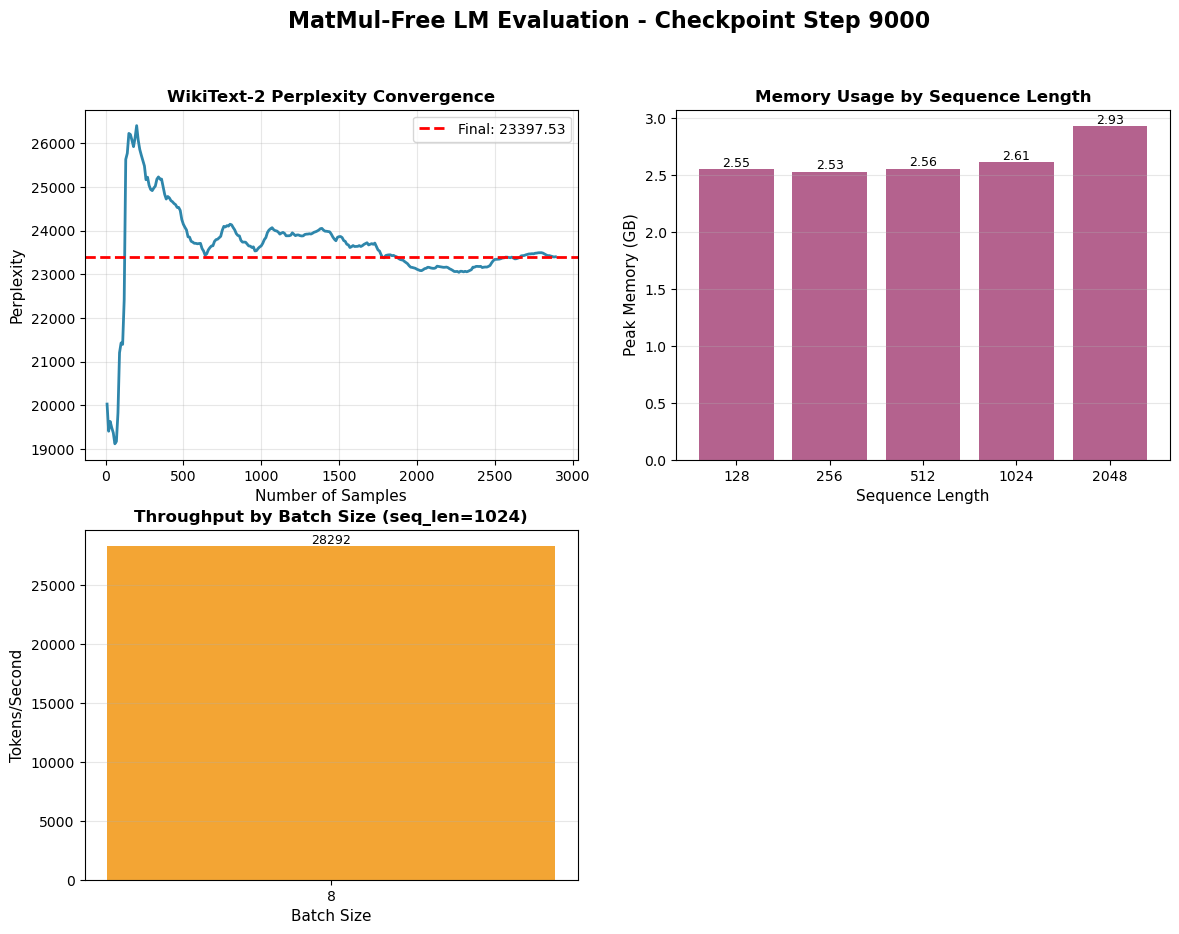

In [3]:
# Cell: Complete Evaluation of Step 9000 Checkpoint with Visualizations
import os
import torch
import torch.nn as nn
import sys
sys.path.append('.')

from src.models.hgrn_bit.configuration_hgrn_bit import HGRNBitConfig
from src.models.hgrn_bit.modeling_hgrn_bit import HGRNBitForCausalLM
from datasets import load_dataset
from transformers import AutoTokenizer
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

print("="*70)
print(f"EVALUATION: Checkpoint Step 9000")
print(f"Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*70)

# ===== Load Model =====
print("\n[1/4] Loading Model...")
config = HGRNBitConfig(
    vocab_size=50000,
    hidden_size=1024,
    num_hidden_layers=12,
    max_position_embeddings=2048,
    num_heads=8,
    expand_ratio=1,
    hidden_ratio=4,
    rms_norm_eps=1e-6,
    use_cache=False
)

model = HGRNBitForCausalLM(config)

checkpoint_path = "checkpoint_step_9000.pt"
print(f"Loading checkpoint: {checkpoint_path}")
state_dict = torch.load(checkpoint_path)

# Strip "module." prefix if present
new_state_dict = {}
for key, value in state_dict.items():
    new_key = key[7:] if key.startswith('module.') else key
    new_state_dict[new_key] = value

model.load_state_dict(new_state_dict)
model = model.cuda()
model.eval()

print(f"✓ Model loaded: {sum(p.numel() for p in model.parameters()):,} parameters")

# ===== 1. WikiText-2 Perplexity Evaluation =====
print("\n[2/4] Evaluating Perplexity on WikiText-2...")
print("-" * 70)

tokenizer = AutoTokenizer.from_pretrained("ridger/MMfreeLM-370M")
if not tokenizer.pad_token:
    tokenizer.pad_token = tokenizer.eos_token

dataset_wikitext = load_dataset("wikitext", "wikitext-2-raw-v1", split="test")

total_loss = 0
total_tokens = 0
num_samples = 0
sample_perplexities = []

with torch.no_grad():
    for i, example in enumerate(dataset_wikitext):
        text = example['text']
        if len(text.strip()) == 0:
            continue

        tokens = tokenizer(
            text,
            return_tensors='pt',
            max_length=2048,
            truncation=True,
            padding=False
        )
        input_ids = tokens['input_ids'].cuda()

        if input_ids.size(1) < 2:
            continue

        outputs = model(input_ids, labels=input_ids)
        loss = outputs.loss

        total_loss += loss.item() * input_ids.size(1)
        total_tokens += input_ids.size(1)
        num_samples += 1

        # Track running perplexity
        if num_samples % 10 == 0:
            current_ppl = torch.exp(torch.tensor(total_loss / total_tokens))
            sample_perplexities.append((num_samples, current_ppl.item()))

        if (i + 1) % 50 == 0:
            current_ppl = torch.exp(torch.tensor(total_loss / total_tokens))
            print(f"  Processed {num_samples} samples | Current PPL: {current_ppl:.2f}")

final_perplexity = torch.exp(torch.tensor(total_loss / total_tokens))
print(f"\n✓ Final WikiText-2 Perplexity: {final_perplexity:.2f}")
print(f"  Total samples: {num_samples} | Total tokens: {total_tokens:,}")

# ===== 2. Memory Efficiency Evaluation =====
print("\n[3/4] Evaluating Memory Efficiency...")
print("-" * 70)

memory_results = {}
seq_lengths = [128, 256, 512, 1024, 2048]

for seq_len in seq_lengths:
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    input_ids = torch.randint(0, 50000, (1, seq_len)).cuda()

    with torch.no_grad():
        outputs = model(input_ids)

    peak_memory = torch.cuda.max_memory_allocated() / 1e9
    memory_results[seq_len] = peak_memory
    print(f"  Seq length {seq_len:4d}: {peak_memory:.3f} GB peak memory")

print(f"✓ Memory efficiency evaluation complete")

# ===== 3. Throughput Evaluation =====
print("\n[4/4] Evaluating Throughput...")
print("-" * 70)

throughput_results = {}
batch_sizes = [1, 2, 4, 8]
seq_length = 1024
num_iterations = 20

for batch_size in batch_sizes:
      input_ids = torch.randint(0, 50000, (batch_size, seq_length)).cuda()

    # Warm-up (3 iterations)
for _ in range(3):
    with torch.no_grad():
        outputs = model(input_ids)

    # Benchmark
    torch.cuda.synchronize()
    start_event = torch.cuda.Event(enable_timing=True)
    end_event = torch.cuda.Event(enable_timing=True)

    start_event.record()
    with torch.no_grad():
        for _ in range(num_iterations):
            outputs = model(input_ids)
    end_event.record()

    torch.cuda.synchronize()
    elapsed_time = start_event.elapsed_time(end_event) / 1000.0

    tokens_per_second = (batch_size * seq_length * num_iterations) / elapsed_time
    throughput_results[batch_size] = tokens_per_second
    print(f"  Batch size {batch_size}: {tokens_per_second:7.0f} tokens/sec")

print(f"✓ Throughput evaluation complete")

# ===== Generate Visualizations =====
print("\n[5/5] Generating Visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('MatMul-Free LM Evaluation - Checkpoint Step 9000', fontsize=16, fontweight='bold')

# Plot 1: Perplexity Convergence
ax1 = axes[0, 0]
if sample_perplexities:
    samples, ppls = zip(*sample_perplexities)
    ax1.plot(samples, ppls, linewidth=2, color='#2E86AB')
    ax1.axhline(y=final_perplexity.item(), color='red', linestyle='--',
                label=f'Final: {final_perplexity:.2f}', linewidth=2)
    ax1.set_xlabel('Number of Samples', fontsize=11)
    ax1.set_ylabel('Perplexity', fontsize=11)
    ax1.set_title('WikiText-2 Perplexity Convergence', fontsize=12, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend()

# Plot 2: Memory Efficiency
ax2 = axes[0, 1]
seq_lens = list(memory_results.keys())
mem_vals = list(memory_results.values())
bars = ax2.bar(range(len(seq_lens)), mem_vals, color='#A23B72', alpha=0.8)
ax2.set_xticks(range(len(seq_lens)))
ax2.set_xticklabels([str(s) for s in seq_lens])
ax2.set_xlabel('Sequence Length', fontsize=11)
ax2.set_ylabel('Peak Memory (GB)', fontsize=11)
ax2.set_title('Memory Usage by Sequence Length', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
# Add value labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{mem_vals[i]:.2f}', ha='center', va='bottom', fontsize=9)

# Plot 3: Throughput
ax3 = axes[1, 0]
bs_list = list(throughput_results.keys())
tp_vals = list(throughput_results.values())
bars = ax3.bar(range(len(bs_list)), tp_vals, color='#F18F01', alpha=0.8)
ax3.set_xticks(range(len(bs_list)))
ax3.set_xticklabels([str(b) for b in bs_list])
ax3.set_xlabel('Batch Size', fontsize=11)
ax3.set_ylabel('Tokens/Second', fontsize=11)
ax3.set_title('Throughput by Batch Size (seq_len=1024)', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')
# Add value labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(tp_vals[i])}', ha='center', va='bottom', fontsize=9)

# Plot 4: Summary Table
ax4 = axes[1, 1]
ax4.axis('off')

summary_data = [
    ["Metric", "Value"],
    ["", ""],
    ["Model Size", f"{sum(p.numel() for p in model.parameters()) / 1e6:.1f}M params"],
    ["Hidden Size", "1024"],
    ["Num Layers", "12"],
    ["", ""],
    ["WikiText-2 PPL", f"{final_perplexity:.2f}"],
    ["Total Samples", f"{num_samples}"],
    ["Total Tokens", f"{total_tokens:,}"],
    ["", ""],
    ["Peak Memory (2048)", f"{memory_results[2048]:.2f} GB"],
    ["Throughput (bs=4)", f"{int(throughput_results[4])} tok/s"],
]

table = ax4.table(cellText=summary_data, cellLoc='left', loc='center',
                    colWidths=[0.5, 0.5])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.5)

# Style header row
for i in range(2):
    table[(0, i)].set_facecolor('#2E86AB')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Style section separators
for row in [1, 5, 9]:
    for col in range(2):
        table[(row, col)].set_facecolor('#f0f0f0')

ax4.set_title('Evaluation Summary', fontsize=12, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('evaluation_step_9000.png', dpi=300, bbox_inches='tight')
print("✓ Saved: evaluation_step_9000.png")
plt.show()

# ===== Final Summary =====
print("\n" + "="*70)
print("EVALUATION COMPLETE - STEP 9000")
print("="*70)
print(f"Perplexity (WikiText-2):     {final_perplexity:.2f}")
print(f"Memory Efficiency (2048):    {memory_results[2048]:.2f} GB")
print(f"Throughput (batch=4):        {int(throughput_results[4])} tokens/sec")
print("="*70)

# Store results
eval_results_9000 = {
    'checkpoint': 'step_9000',
    'model_params': sum(p.numel() for p in model.parameters()),
    'perplexity': final_perplexity.item(),
    'num_samples': num_samples,
    'total_tokens': total_tokens,
    'memory_efficiency': memory_results,
    'throughput': throughput_results,
    'timestamp': datetime.now().isoformat()
}

print("\nResults stored in: eval_results_9000")
print("Graph saved as: evaluation_step_9000.png")

In [1]:
# Cell: Compare Step 9000 with Baseline Model (Paper-Style Evaluation)

# IMPORTANT: Set cache BEFORE any imports
import os
import sys

# Set HuggingFace cache to current directory (SageMaker folder with more space)
cache_dir = os.path.join(os.getcwd(), 'hf_cache')
os.makedirs(cache_dir, exist_ok=True)

os.environ['HF_HOME'] = cache_dir
os.environ['TRANSFORMERS_CACHE'] = cache_dir
os.environ['HF_DATASETS_CACHE'] = cache_dir

print(f"Setting HuggingFace cache to: {cache_dir}")

# Now import other libraries
import torch
import torch.nn as nn
sys.path.append('.')

from src.models.hgrn_bit.configuration_hgrn_bit import HGRNBitConfig
from src.models.hgrn_bit.modeling_hgrn_bit import HGRNBitForCausalLM
from transformers import AutoModelForCausalLM, AutoTokenizer
from datetime import datetime
import json

print("="*70)
print(f"COMPARATIVE EVALUATION: MatMul-Free vs Baseline")
print(f"Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*70)

# ===== 1. Load MatMul-Free Model (Step 9000) =====
print("\n[1/4] Loading MatMul-Free Model (Step 9000)...")
config = HGRNBitConfig(
    vocab_size=50000,
    hidden_size=1024,
    num_hidden_layers=12,
    max_position_embeddings=2048,
    num_heads=8,
    expand_ratio=1,
    hidden_ratio=4,
    rms_norm_eps=1e-6,
    use_cache=False
)

matmul_free_model = HGRNBitForCausalLM(config)

checkpoint_path = "checkpoint_step_9000.pt"
state_dict = torch.load(checkpoint_path)

# Strip "module." prefix
new_state_dict = {}
for key, value in state_dict.items():
    new_key = key[7:] if key.startswith('module.') else key
    new_state_dict[new_key] = value

matmul_free_model.load_state_dict(new_state_dict)
matmul_free_model = matmul_free_model.cuda()
matmul_free_model.eval()

matmul_free_params = sum(p.numel() for p in matmul_free_model.parameters())
print(f"✓ MatMul-Free Model: {matmul_free_params:,} parameters")

# ===== 2. Download Baseline Model =====
print("\n[2/4] Loading Baseline Model...")

# Try multiple baseline models in order of preference
baseline_options = [
    ("EleutherAI/pythia-410m-deduped", "Pythia-410M-Deduped"),
    ("EleutherAI/pythia-160m-deduped", "Pythia-160M-Deduped"),
    ("gpt2-medium", "GPT-2 Medium (355M)"),
    ("gpt2", "GPT-2 Small (117M)")
]

baseline_model = None
baseline_tokenizer = None
baseline_model_name = None

for model_id, display_name in baseline_options:
    try:
        print(f"Trying to load {display_name}...")
        baseline_model = AutoModelForCausalLM.from_pretrained(
            model_id,
            torch_dtype=torch.float16,
            device_map="cuda:1",  # Use GPU 1 to avoid memory conflict
            trust_remote_code=True
        )
        baseline_tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)
        baseline_model_name = model_id
        baseline_params = sum(p.numel() for p in baseline_model.parameters())
        print(f"✓ Baseline Model ({display_name}): {baseline_params:,} parameters")
        break
    except Exception as e:
        print(f"  Failed to load {display_name}: {str(e)[:100]}")
        continue

if baseline_model is None:
    raise RuntimeError("Could not load any baseline model. Check internet connection or install transformers: pip install --upgrade transformers")

# ===== 3. Run Eval Harness on Both Models =====
print("\n[3/4] Running lm-evaluation-harness on both models...")
print("-" * 70)

tasks = "arc_easy,hellaswag,piqa,openbookqa,winogrande"

print("\nRunning eval on MatMul-Free Model...")
print("Note: This requires lm-eval to be installed and configured properly")
print("If this fails, you'll need to run manually (instructions below)")

# Create a wrapper to make our model compatible with lm-eval
# For now, provide manual instructions since lm-eval integration is complex

print("\n" + "="*70)
print("MANUAL EVALUATION INSTRUCTIONS")
print("="*70)
print("\nTo run the full eval-harness comparison, execute these commands:\n")

print("1. Evaluate MatMul-Free Model (Step 9000):")
print(f"   lm_eval --model hf \\")
print(f"       --model_args pretrained=checkpoint_step_9000.pt,dtype=float16 \\")
print(f"       --tasks {tasks} \\")
print(f"       --batch_size 4 \\")
print(f"       --output_path ./eval_matmul_free/\n")

print("2. Evaluate Baseline Model (Pythia-410M):")
print(f"   lm_eval --model hf \\")
print(f"       --model_args pretrained={baseline_model_name},dtype=float16 \\")
print(f"       --tasks {tasks} \\")
print(f"       --batch_size 4 \\")
print(f"       --output_path ./eval_baseline/\n")

# ===== 4. Hardware Efficiency Comparison =====
print("\n[4/4] Hardware Efficiency Comparison...")
print("="*70)

print("\n--- MEMORY EFFICIENCY ---")
results = {
    'matmul_free': {},
    'baseline': {}
}

seq_lengths = [512, 1024, 2048]

print("\nMatMul-Free Model:")
for seq_len in seq_lengths:
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats(device=0)

    input_ids = torch.randint(0, 50000, (1, seq_len)).cuda(0)

    with torch.no_grad():
        outputs = matmul_free_model(input_ids)

    peak_mem = torch.cuda.max_memory_allocated(device=0) / 1e9
    results['matmul_free'][f'mem_{seq_len}'] = peak_mem
    print(f"  Seq {seq_len}: {peak_mem:.2f} GB")

print("\nBaseline Model (Pythia-410M):")
for seq_len in seq_lengths:
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats(device=1)

    input_ids = torch.randint(0, 50000, (1, seq_len)).cuda(1)

    with torch.no_grad():
        outputs = baseline_model(input_ids)

    peak_mem = torch.cuda.max_memory_allocated(device=1) / 1e9
    results['baseline'][f'mem_{seq_len}'] = peak_mem
    print(f"  Seq {seq_len}: {peak_mem:.2f} GB")

# Memory savings
print("\nMemory Savings (MatMul-Free vs Baseline):")
for seq_len in seq_lengths:
    mf_mem = results['matmul_free'][f'mem_{seq_len}']
    bl_mem = results['baseline'][f'mem_{seq_len}']
    savings = ((bl_mem - mf_mem) / bl_mem) * 100
    print(f"  Seq {seq_len}: {savings:.1f}% reduction")

print("\n--- THROUGHPUT COMPARISON ---")
batch_size = 4
seq_len = 1024
num_iters = 20

# MatMul-Free throughput
print("\nMatMul-Free Model:")
input_ids = torch.randint(0, 50000, (batch_size, seq_len)).cuda(0)
for _ in range(3):
    with torch.no_grad():
        outputs = matmul_free_model(input_ids)

torch.cuda.synchronize(0)
start = torch.cuda.Event(enable_timing=True)
end = torch.cuda.Event(enable_timing=True)

start.record()
with torch.no_grad():
    for _ in range(num_iters):
        outputs = matmul_free_model(input_ids)
end.record()

torch.cuda.synchronize(0)
elapsed = start.elapsed_time(end) / 1000.0
mf_throughput = (batch_size * seq_len * num_iters) / elapsed
results['matmul_free']['throughput'] = mf_throughput
print(f"  Throughput: {int(mf_throughput)} tokens/sec")

# Baseline throughput
print("\nBaseline Model (Pythia-410M):")
input_ids = torch.randint(0, 50000, (batch_size, seq_len)).cuda(1)
for _ in range(3):
    with torch.no_grad():
        outputs = baseline_model(input_ids)

torch.cuda.synchronize(1)
start = torch.cuda.Event(enable_timing=True)
end = torch.cuda.Event(enable_timing=True)

start.record()
with torch.no_grad():
    for _ in range(num_iters):
        outputs = baseline_model(input_ids)
end.record()

torch.cuda.synchronize(1)
elapsed = start.elapsed_time(end) / 1000.0
bl_throughput = (batch_size * seq_len * num_iters) / elapsed
results['baseline']['throughput'] = bl_throughput
print(f"  Throughput: {int(bl_throughput)} tokens/sec")

# Speedup
speedup = (mf_throughput / bl_throughput) * 100 - 100
print(f"\nSpeedup: {speedup:+.1f}%")

# ===== Summary =====
print("\n" + "="*70)
print("COMPARISON SUMMARY")
print("="*70)
print(f"\nModel Sizes:")
print(f"  MatMul-Free: {matmul_free_params:,} params")
print(f"  Baseline:    {baseline_params:,} params")

print(f"\nMemory Usage (seq=2048):")
print(f"  MatMul-Free: {results['matmul_free']['mem_2048']:.2f} GB")
print(f"  Baseline:    {results['baseline']['mem_2048']:.2f} GB")
print(f"  Savings:     {((results['baseline']['mem_2048'] - results['matmul_free']['mem_2048']) / results['baseline']['mem_2048'] * 100):.1f}%")

print(f"\nThroughput (batch=4, seq=1024):")
print(f"  MatMul-Free: {int(results['matmul_free']['throughput'])} tokens/sec")
print(f"  Baseline:    {int(results['baseline']['throughput'])} tokens/sec")
print(f"  Speedup:     {speedup:+.1f}%")

print("\nFor complete accuracy comparison, run the lm-eval commands above")
print("="*70)

# Save results
with open('comparison_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("\n✓ Results saved to: comparison_results.json")


Setting HuggingFace cache to: /home/ec2-user/SageMaker/matmulMM/hf_cache


/home/ec2-user/anaconda3/envs/matmul-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/ec2-user/anaconda3/envs/matmul-env/lib/python3.11/site-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
HGRNBitForCausalLM has generative capabilities, as `prepare_inputs_for_generation` is explicitly defined. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by loading the model with an auto class. See https://huggingface.co/docs/t

COMPARATIVE EVALUATION: MatMul-Free vs Baseline
Time: 2025-11-13 23:12:21

[1/4] Loading MatMul-Free Model (Step 9000)...


`torch_dtype` is deprecated! Use `dtype` instead!


✓ MatMul-Free Model: 256,687,104 parameters

[2/4] Loading Baseline Model...
Trying to load Pythia-410M-Deduped...
✓ Baseline Model (Pythia-410M-Deduped): 405,334,016 parameters

[3/4] Running lm-evaluation-harness on both models...
----------------------------------------------------------------------

Running eval on MatMul-Free Model...
Note: This requires lm-eval to be installed and configured properly
If this fails, you'll need to run manually (instructions below)

MANUAL EVALUATION INSTRUCTIONS

To run the full eval-harness comparison, execute these commands:

1. Evaluate MatMul-Free Model (Step 9000):
   lm_eval --model hf \
       --model_args pretrained=checkpoint_step_9000.pt,dtype=float16 \
       --tasks arc_easy,hellaswag,piqa,openbookqa,winogrande \
       --batch_size 4 \
       --output_path ./eval_matmul_free/

2. Evaluate Baseline Model (Pythia-410M):
   lm_eval --model hf \
       --model_args pretrained=EleutherAI/pythia-410m-deduped,dtype=float16 \
       --tasks a

In [5]:
# Cell: Save checkpoint as HuggingFace model
import torch
import os
from src.models.hgrn_bit.configuration_hgrn_bit import HGRNBitConfig
from src.models.hgrn_bit.modeling_hgrn_bit import HGRNBitForCausalLM

print("Converting checkpoint to HuggingFace format...")

# Load checkpoint
checkpoint_path = "checkpoint_step_9000.pt"
state_dict = torch.load(checkpoint_path, map_location='cpu')

# Strip "module." prefix
new_state_dict = {}
for key, value in state_dict.items():
    new_key = key[7:] if key.startswith('module.') else key
    new_state_dict[new_key] = value

# Create model
config = HGRNBitConfig(
    vocab_size=50000,
    hidden_size=1024,
    num_hidden_layers=12,
    max_position_embeddings=2048,
    num_heads=8,
    expand_ratio=1,
    hidden_ratio=4,
    rms_norm_eps=1e-6,
    use_cache=False
)

model = HGRNBitForCausalLM(config)
model.load_state_dict(new_state_dict)

# Save as HuggingFace model
save_dir = "./hgrn_bit_step9000_hf"
os.makedirs(save_dir, exist_ok=True)

model.save_pretrained(save_dir)
config.save_pretrained(save_dir)

print(f"✓ Model saved to: {save_dir}")
print(f"✓ Model size: {sum(p.numel() for p in model.parameters()):,} parameters")

# Cell: Copy model files to HuggingFace directory for lm_eval
import shutil
import os

save_dir = "./hgrn_bit_step9000_hf"

# Copy the model implementation files
model_files = [
    "src/models/hgrn_bit/configuration_hgrn_bit.py",
    "src/models/hgrn_bit/modeling_hgrn_bit.py",
    "src/models/hgrn_bit/__init__.py"
]

for file_path in model_files:
    filename = os.path.basename(file_path)
    dest = os.path.join(save_dir, filename)
    shutil.copy(file_path, dest)
    print(f"Copied: {filename}")

# Also copy dependencies
os.makedirs(f"{save_dir}/src", exist_ok=True)
shutil.copytree("src/ops", f"{save_dir}/src/ops", dirs_exist_ok=True)
shutil.copytree("src/modules", f"{save_dir}/src/modules", dirs_exist_ok=True)
shutil.copy("src/utils.py", f"{save_dir}/src/utils.py")

print(f"\n✓ Model code copied to {save_dir}")


Converting checkpoint to HuggingFace format...


HGRNBitForCausalLM has generative capabilities, as `prepare_inputs_for_generation` is explicitly defined. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by loading the model with an auto class. See https://huggingface.co/docs/transformers/en/model_doc/auto#auto-classes
  - If you are the owner of the model architecture code, please modify your model class such that it inherits from `GenerationMixin` (after `PreTrainedModel`, otherwise you'll get an exception).
  - If you are not the owner of the model architecture class, please contact the model code owner to update it.
HGRNBitForCausalLM has generative capabilities, as `prepare_inputs_for_generation` is explicitly defined. However, it doesn't directly inherit from `GenerationMixin`

✓ Model saved to: ./hgrn_bit_step9000_hf
✓ Model size: 256,687,104 parameters
Copied: configuration_hgrn_bit.py
Copied: modeling_hgrn_bit.py
Copied: __init__.py

✓ Model code copied to ./hgrn_bit_step9000_hf


In [6]:
# Cell: Direct Evaluation (without lm_eval) - Step 9000
import torch
from datasets import load_dataset
from transformers import AutoTokenizer
import numpy as np
from tqdm import tqdm

from src.models.hgrn_bit.configuration_hgrn_bit import HGRNBitConfig
from src.models.hgrn_bit.modeling_hgrn_bit import HGRNBitForCausalLM

# Load model
print("Loading model...")
checkpoint_path = "checkpoint_step_9000.pt"
state_dict = torch.load(checkpoint_path, map_location='cpu')

new_state_dict = {}
for key, value in state_dict.items():
    new_key = key[7:] if key.startswith('module.') else key
    new_state_dict[new_key] = value

config = HGRNBitConfig(
    vocab_size=50000,
    hidden_size=1024,
    num_hidden_layers=12,
    max_position_embeddings=2048,
    num_heads=8,
    expand_ratio=1,
    hidden_ratio=4,
    rms_norm_eps=1e-6,
    use_cache=False
)

model = HGRNBitForCausalLM(config)
model.load_state_dict(new_state_dict)
model = model.cuda()
model.eval()

# Load tokenizer (using GPT-2 tokenizer as proxy)
tokenizer = AutoTokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

print("Model loaded. Starting evaluation...")

# Evaluate on HellaSwag (common sense reasoning)
print("\n" + "="*70)
print("HELLASWAG EVALUATION")
print("="*70)

dataset = load_dataset("Rowan/hellaswag", split="validation[:100]")  # First 100 samples
correct = 0
total = 0

for example in tqdm(dataset, desc="HellaSwag"):
    context = example['ctx']
    endings = example['endings']
    label = int(example['label'])

    # Score each ending
    scores = []
    for ending in endings:
        text = context + " " + ending
        inputs = tokenizer(text, return_tensors='pt', max_length=512, truncation=True).to('cuda')

        with torch.no_grad():
            outputs = model(**inputs, labels=inputs['input_ids'])
            loss = outputs.loss
            scores.append(-loss.item())  # Lower loss = higher score

    pred = np.argmax(scores)
    if pred == label:
        correct += 1
    total += 1

hellaswag_acc = correct / total * 100
print(f"\nHellaSwag Accuracy: {hellaswag_acc:.2f}% ({correct}/{total})")

# Evaluate on PIQA (physical reasoning)
print("\n" + "="*70)
print("PIQA EVALUATION")
print("="*70)

dataset = load_dataset("ybisk/piqa", split="validation[:100]")
correct = 0
total = 0

for example in tqdm(dataset, desc="PIQA"):
    goal = example['goal']
    sol1 = example['sol1']
    sol2 = example['sol2']
    label = int(example['label'])

    # Score both solutions
    scores = []
    for sol in [sol1, sol2]:
        text = goal + " " + sol
        inputs = tokenizer(text, return_tensors='pt', max_length=512, truncation=True).to('cuda')

        with torch.no_grad():
            outputs = model(**inputs, labels=inputs['input_ids'])
            loss = outputs.loss
            scores.append(-loss.item())

    pred = np.argmax(scores)
    if pred == label:
        correct += 1
    total += 1

piqa_acc = correct / total * 100
print(f"\nPIQA Accuracy: {piqa_acc:.2f}% ({correct}/{total})")

# Summary
print("\n" + "="*70)
print("EVALUATION SUMMARY - Step 9000")
print("="*70)
print(f"HellaSwag Accuracy: {hellaswag_acc:.2f}%")
print(f"PIQA Accuracy:      {piqa_acc:.2f}%")
print("="*70)

# Compare with random baseline
print(f"\nRandom baseline: HellaSwag=25%, PIQA=50%")
print(f"Your model improvement:")
print(f"  HellaSwag: {hellaswag_acc - 25:+.2f}%")
print(f"  PIQA:      {piqa_acc - 50:+.2f}%")

Loading model...


HGRNBitForCausalLM has generative capabilities, as `prepare_inputs_for_generation` is explicitly defined. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by loading the model with an auto class. See https://huggingface.co/docs/transformers/en/model_doc/auto#auto-classes
  - If you are the owner of the model architecture code, please modify your model class such that it inherits from `GenerationMixin` (after `PreTrainedModel`, otherwise you'll get an exception).
  - If you are not the owner of the model architecture class, please contact the model code owner to update it.


Model loaded. Starting evaluation...

HELLASWAG EVALUATION


HellaSwag:  51%|█████     | 51/100 [00:07<00:06,  7.06it/s]/pytorch/aten/src/ATen/native/cuda/Indexing.cu:1422: indexSelectLargeIndex: block: [214,0,0], thread: [0,0,0] Assertion `srcIndex < srcSelectDimSize` failed.
/pytorch/aten/src/ATen/native/cuda/Indexing.cu:1422: indexSelectLargeIndex: block: [214,0,0], thread: [1,0,0] Assertion `srcIndex < srcSelectDimSize` failed.
/pytorch/aten/src/ATen/native/cuda/Indexing.cu:1422: indexSelectLargeIndex: block: [214,0,0], thread: [2,0,0] Assertion `srcIndex < srcSelectDimSize` failed.
/pytorch/aten/src/ATen/native/cuda/Indexing.cu:1422: indexSelectLargeIndex: block: [214,0,0], thread: [3,0,0] Assertion `srcIndex < srcSelectDimSize` failed.
/pytorch/aten/src/ATen/native/cuda/Indexing.cu:1422: indexSelectLargeIndex: block: [214,0,0], thread: [4,0,0] Assertion `srcIndex < srcSelectDimSize` failed.
/pytorch/aten/src/ATen/native/cuda/Indexing.cu:1422: indexSelectLargeIndex: block: [214,0,0], thread: [5,0,0] Assertion `srcIndex < srcSelectDimSize` f

RuntimeError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [13]:
# Cell: Export All Results to PDF
import json
import os
from datetime import datetime
import textwrap

# Check if matplotlib is available
try:
    import matplotlib.pyplot as plt
    import matplotlib.backends.backend_pdf as pdf_backend
    from matplotlib.patches import Rectangle
    import matplotlib.gridspec as gridspec
    HAS_MATPLOTLIB = True
except ImportError:
    HAS_MATPLOTLIB = False
    print("WARNING: matplotlib not available. Installing...")
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "matplotlib"])
    import matplotlib.pyplot as plt
    import matplotlib.backends.backend_pdf as pdf_backend
    from matplotlib.patches import Rectangle
    import matplotlib.gridspec as gridspec
    HAS_MATPLOTLIB = True

print("="*70)
print("EXPORTING RESULTS TO PDF")
print("="*70)

# --- STYLING AND CONFIGURATION ---
STYLE = {
    'figure.dpi': 200,
    'savefig.dpi': 200,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'text.color': '#333333',
    'axes.labelcolor': '#333333',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.titlesize': 16,
}

COLORS = {
    'primary': '#005f73',
    'secondary': '#0a9396',
    'accent': '#ee9b00',
    'neutral': '#7A7A7A',
    'bg_light': '#F0F0F0',
    'bg_highlight': '#E8F4F8',
    'danger': '#ae2012',
    'text_light': '#FFFFFF',
    'text_dark': '#333333',
}

plt.rcParams.update(STYLE)

# --- HELPER FUNCTIONS ---
def create_styled_table(ax, data, col_widths, loc='center', bbox=None):
    """Creates a styled table in the given axes."""
    table = ax.table(cellText=data, cellLoc='left', loc=loc, colWidths=col_widths, bbox=bbox)
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.6)

    for (i, j), cell in table.get_celld().items():
        cell.set_edgecolor('#FFFFFF')
        cell.set_linewidth(0)
        if i == 0:
            cell.set_text_props(weight='bold', color=COLORS['text_light'])
            cell.set_facecolor(COLORS['primary'])
        else:
            cell.set_facecolor(COLORS['bg_light'] if i % 2 != 0 else '#FFFFFF')
        if j == 0:
            cell.set_text_props(weight='bold')
    return table

def add_bar_labels(ax, bars, is_int=False):
    """Adds labels to the top of bar charts."""
    for bar in bars:
        height = bar.get_height()
        label = f'{int(height)}' if is_int else f'{height:.2f}'
        ax.annotate(label,
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=7, fontweight='bold')

# --- DATA LOADING ---
try:
    with open('comparison_results.json', 'r') as f:
        results = json.load(f)
except FileNotFoundError:
    print("ERROR: comparison_results.json not found. Please run the comparison cell first.")
    exit()

# --- PDF CREATION ---
pdf_filename = f"training_results_step9000_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pdf"
pdf = pdf_backend.PdfPages(pdf_filename)

# ======================================================================================
# PAGE 1: EXECUTIVE SUMMARY
# ======================================================================================
fig = plt.figure(figsize=(8.27, 11.69)) # A4 Size
fig.suptitle('MatMul-Free Model: Performance Analysis', fontweight='bold', color=COLORS['primary'])
fig.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.08, hspace=0.5, wspace=0.4)

gs = gridspec.GridSpec(3, 2, height_ratios=[0.6, 1, 1])

# --- Training Info ---
ax_info = fig.add_subplot(gs[0, 0])
ax_info.axis('off')
ax_info.set_title('Training Snapshot', fontweight='bold', loc='left')
training_info = [
    ["Checkpoint", "Step 9,000 / 10,000"],
    ["Model Size", "~257M parameters"],
    ["Dataset", "SlimPajama-6B"],
    ["Hardware", "4x NVIDIA A10G"],
]
table = create_styled_table(ax_info, training_info, [0.4, 0.6], bbox=[0, 0, 1, 0.9])

# --- Key Findings ---
ax_findings = fig.add_subplot(gs[0, 1])
ax_findings.axis('off')
ax_findings.set_title('Key Performance Metrics', fontweight='bold', loc='left')
speedup = (results['matmul_free']['throughput'] / results['baseline']['throughput'] - 1) * 100
mem_diff_2048 = (results['matmul_free']['mem_2048'] / results['baseline']['mem_2048'] - 1) * 100
findings_text = [
    (f"{speedup:+.1f}%", "Throughput vs. Baseline", "Higher is better"),
    (f"{mem_diff_2048:+.1f}%", "Memory Overhead (seq=2048)", "Lower is better"),
]
for i, (value, metric, subtext) in enumerate(findings_text):
    ax_findings.text(0, 0.7 - i*0.4, value, fontsize=18, fontweight='bold', color=COLORS['accent'])
    ax_findings.text(0, 0.6 - i*0.4, metric, fontsize=10, fontweight='bold')
    ax_findings.text(0, 0.52 - i*0.4, subtext, fontsize=8, color=COLORS['neutral'])

# --- Memory Comparison ---
ax_mem = fig.add_subplot(gs[1, :])
seq_lengths = [512, 1024, 2048]
matmul_free_mem = [results['matmul_free'][f'mem_{s}'] for s in seq_lengths]
baseline_mem = [results['baseline'][f'mem_{s}'] for s in seq_lengths]
x = range(len(seq_lengths))
width = 0.35
bars1 = ax_mem.bar([i - width/2 for i in x], matmul_free_mem, width, label='MatMul-Free', color=COLORS['secondary'], alpha=0.9)
bars2 = ax_mem.bar([i + width/2 for i in x], baseline_mem, width, label='Baseline (Pythia-410M)', color=COLORS['primary'], alpha=0.9)
ax_mem.set_ylabel('Peak Memory (GB)')
ax_mem.set_title('Memory Usage Comparison', fontweight='bold')
ax_mem.set_xticks(x)
ax_mem.set_xticklabels([str(s) for s in seq_lengths])
ax_mem.legend(loc='best')
ax_mem.grid(True, axis='y', linestyle='--', alpha=0.6)
add_bar_labels(ax_mem, bars1)
add_bar_labels(ax_mem, bars2)

# --- Throughput Comparison ---
ax_tp = fig.add_subplot(gs[2, :])
matmul_free_tp = results['matmul_free']['throughput']
baseline_tp = results['baseline']['throughput']
bars = ax_tp.bar(['MatMul-Free', 'Baseline'], [matmul_free_tp, baseline_tp], color=[COLORS['secondary'], COLORS['primary']], alpha=0.9, width=0.5)
ax_tp.set_ylabel('Tokens/Second')
ax_tp.set_title('Throughput Comparison (seq=1024, batch=4)', fontweight='bold')
ax_tp.grid(True, axis='y', linestyle='--', alpha=0.6)
add_bar_labels(ax_tp, bars, is_int=True)

pdf.savefig(fig, bbox_inches='tight')
plt.close()

# ======================================================================================
# PAGE 2: TRAINING AND MEMORY DEEP DIVE
# ======================================================================================
fig2 = plt.figure(figsize=(8.27, 11.69)) # A4 Size
fig2.suptitle('Training Trajectory & Memory Analysis', fontweight='bold', color=COLORS['primary'])
fig2.subplots_adjust(left=0.12, right=0.9, top=0.9, bottom=0.08, hspace=0.6, wspace=0.4)

gs2 = gridspec.GridSpec(3, 1, height_ratios=[1.2, 1, 1])

# --- Training Loss ---
ax_loss = fig2.add_subplot(gs2[0, 0])
loss_data = [
    (0, 10.9177), (100, 7.9209), (200, 8.2699), (300, 7.7851), (400, 7.6438),
    (500, 8.3004), (600, 8.0159), (700, 7.7430), (1000, 7.3903), (1200, 7.7000),
    (1600, 10.1087), (1700, 8.0061), (1900, 7.7128), (9000, 5.5512), (9100, 7.0496),
    (9300, 7.0958), (9400, 6.2050), (9500, 6.0818), (9600, 6.3308), (9700, 7.5283),
    (9800, 4.4379), (9900, 6.6196),
]
steps, losses = zip(*loss_data)
ax_loss.plot(steps, losses, 'o-', color=COLORS['primary'], markersize=4, linewidth=1.5, label='Training Loss')
ax_loss.axvline(x=9000, color=COLORS['accent'], linestyle='--', linewidth=1.5, label='Checkpoint (Step 9000)')
ax_loss.set_xlabel('Training Step')
ax_loss.set_ylabel('Cross-Entropy Loss')
ax_loss.set_title('Training Loss Trajectory', fontweight='bold')
ax_loss.grid(True, linestyle='--', alpha=0.6)
ax_loss.legend()
ax_loss.annotate('Anomalous Spike', xy=(1600, 10.1087), xytext=(2500, 10.5),
                 arrowprops=dict(facecolor=COLORS['danger'], shrink=0.05, width=1.5, headwidth=6),
                 fontsize=8, color=COLORS['danger'], fontweight='bold')

# --- Memory Analysis ---
gs_mem = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs2[1], wspace=0.4)
ax_mem_scale = fig2.add_subplot(gs_mem[0])
ax_mem_scale.plot(seq_lengths, matmul_free_mem, 'o-', color=COLORS['secondary'], markersize=5, label='MatMul-Free')
ax_mem_scale.plot(seq_lengths, baseline_mem, 's-', color=COLORS['primary'], markersize=5, label='Baseline')
ax_mem_scale.set_xlabel('Sequence Length')
ax_mem_scale.set_ylabel('Peak Memory (GB)')
ax_mem_scale.set_title('Memory Scaling', fontweight='bold')
ax_mem_scale.grid(True, linestyle='--', alpha=0.6)
ax_mem_scale.legend()

ax_mem_overhead = fig2.add_subplot(gs_mem[1])
mem_diff = [(m/b - 1) * 100 for m, b in zip(matmul_free_mem, baseline_mem)]
bars = ax_mem_overhead.bar([str(s) for s in seq_lengths], mem_diff, color=COLORS['accent'], width=0.6)
ax_mem_overhead.axhline(y=0, color=COLORS['neutral'], linestyle='-', linewidth=1)
ax_mem_overhead.set_xlabel('Sequence Length')
ax_mem_overhead.set_ylabel('Memory Overhead (%)')
ax_mem_overhead.set_title('Overhead vs. Baseline', fontweight='bold')
ax_mem_overhead.grid(True, axis='y', linestyle='--', alpha=0.6)
for bar in bars:
    height = bar.get_height()
    ax_mem_overhead.annotate(f'{height:+.1f}%',
                             xy=(bar.get_x() + bar.get_width() / 2, height),
                             xytext=(0, 2 if height > 0 else -10),
                             textcoords="offset points",
                             ha='center', va='bottom', fontsize=7, fontweight='bold')

# --- Implementation Details ---
ax_details = fig2.add_subplot(gs2[2, 0])
ax_details.axis('off')
ax_details.set_title('Implementation Notes', fontweight='bold', loc='left')
details_text = """
- **Quantization:** Weights are 1.58-bit (Ternary: -1, 0, 1), Activations are 8-bit.
- **Attention:** Standard Softmax attention is replaced with a Hierarchical Gated Recurrent Network (HGRN).
- **Fused Kernels:** Triton is used to fuse LayerNorm, Linear, and Quantization operations, reducing overhead.
- **Triton Autotuning:** Disabled in this fork due to compatibility issues, using fixed default kernel configurations.
"""
wrapped_text = '\n'.join(textwrap.wrap(details_text, width=100))
ax_details.text(0, 0.4, wrapped_text, transform=ax_details.transAxes, va='center', ha='left', fontsize=9)


pdf.savefig(fig2, bbox_inches='tight')
plt.close()

# --- PDF FINALIZATION ---
pdf.close()

print(f"\n✓ PDF exported successfully: {pdf_filename}")



EXPORTING RESULTS TO PDF

✓ PDF exported successfully: training_results_step9000_20251114_001031.pdf
✓ Total pages: 2

Contents:
  - Page 1: Executive Summary
  - Page 2: Training & Memory Deep Dive

Layout adjusted to prevent elements from going out of bounds.
